# Exploratory Data Analysis 

**Objective:** analyze `accounts.csv`, `alerts.csv` and `transactions.csv`, verify data quality and integrity, and characterize the structure of the problem prior to feature engineering.

**Questions addressed:**

- What each file contains (sections 2, 2.1)
- Number of accounts and transactions (sections 2, 7.2)
- Number and percentage of suspicious/SAR accounts (sections 4.1, 7.2)
- Class imbalance and its implications (sections 4.1, 7.3)
- Important limitations of the synthetic dataset (section 7.4)

**Contents:**
1. Setup and libraries
2. Data loading and data dictionary
3. Data quality verification and cleaning
4. Univariate EDA
5. Bivariate EDA (relationship with the target `IS_FRAUD`)
6. Network pattern visualization and verification (`cycle` and `fan_in`)
7. Summary of findings and decisions
8. Export of verified data


## 1. Setup and libraries

**Rationale for each library:**

- **pandas / numpy** — tabular manipulation and vectorized operations. The data volume (10K accounts, 1.3M transactions) fits in memory; distributed processing is not required.
- **matplotlib** — base plotting engine, providing control over figure size, DPI and style.
- **seaborn** — built on matplotlib, with statistical defaults suited to comparing distributions across groups (fraudulent vs. legitimate).
- **scipy.stats** — Mann-Whitney U test, used to verify whether differences observed visually between classes are statistically significant.
- **missingno** — visualization of missing values.
- **networkx** — the two typologies present (`cycle` and `fan_in`) are graph patterns; networkx allows them to be reconstructed and formally verified.

`scikit-learn`, `xgboost` and `shap` are introduced in the feature engineering and modeling notebook.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import networkx as nx
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded.")

Libraries loaded.


## 2. Data loading

The three provided files are loaded as delivered; no additional data is generated.

In [4]:
DATA_DIR = "./"

accounts = pd.read_csv(DATA_DIR + "accounts.csv")
alerts = pd.read_csv(DATA_DIR + "alerts.csv")
transactions = pd.read_csv(DATA_DIR + "transactions.csv")

print("accounts:", accounts.shape)
print("alerts:", alerts.shape)
print("transactions:", transactions.shape)

accounts: (10000, 7)
alerts: (1719, 9)
transactions: (1323234, 8)


In [5]:
accounts.head()

,ACCOUNT_ID,CUSTOMER_ID,INIT_BALANCE,COUNTRY,ACCOUNT_TYPE,IS_FRAUD,TX_BEHAVIOR_ID
0,0,C_0,184.44,US,I,False,1
1,1,C_1,175.80,US,I,False,1
2,2,C_2,142.06,US,I,False,1
3,3,C_3,125.89,US,I,False,1
4,4,C_4,151.13,US,I,False,1


In [ ]:
alerts.head()

,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP
0,193,fan_in,True,82,6976,9739,TRANSFER,4.85,0
1,377,cycle,True,949,5776,2570,TRANSFER,10.27,0
2,189,fan_in,True,6280,9999,9530,TRANSFER,2.74,1
3,377,cycle,True,7999,1089,7352,TRANSFER,10.27,1
4,130,fan_in,True,12975,7025,9708,TRANSFER,3.53,2


In [7]:
transactions.head()

,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID
0,1,6456,9069,TRANSFER,465.05,0,False,-1
1,2,7516,9543,TRANSFER,564.64,0,False,-1
2,3,2445,9356,TRANSFER,598.94,0,False,-1
3,4,2576,4617,TRANSFER,466.07,0,False,-1
4,5,3524,1773,TRANSFER,405.63,0,False,-1


**Contents of each file:**

- **`accounts.csv`** — one row per account (10,000 accounts). Contains the account-level target variable (`IS_FRAUD`), initial balance, country, account type, and a behavior-pattern identifier (`TX_BEHAVIOR_ID`).
- **`alerts.csv`** — the subset of transactions belonging to a known laundering typology (`cycle` or `fan_in`), grouped by `ALERT_ID`. Every row has `IS_FRAUD = True`: it is exclusively the positive set, not a representative sample.
- **`transactions.csv`** — the complete transfer log (1.32M rows). Each row carries an `ALERT_ID` (`-1` when it belongs to no alert). This is the source used to build account-level features.

## 2.1 Data dictionary and observed relationships

Each file is documented column by column, together with the relationships observed directly between columns within each table. Any structural relationship identified here conditions downstream feature engineering and modeling decisions.

### 2.1.1 `accounts.csv`

| Column | Type | Content |
|---|---|---|
| `ACCOUNT_ID` | int | Unique account identifier (0–9999, no duplicates). |
| `CUSTOMER_ID` | string | Format `C_<number>`. |
| `INIT_BALANCE` | float | Initial account balance. |
| `COUNTRY` | string | Account country. |
| `ACCOUNT_TYPE` | string | Account type. |
| `IS_FRAUD` | bool | Account-level target variable. |
| `TX_BEHAVIOR_ID` | int | Behavior pattern assigned by the generator (1–5). |

Three inter-column relationships are verified below.

In [8]:
# 1. Is CUSTOMER_ID a 1:1 function of ACCOUNT_ID?
mismatch = (accounts["CUSTOMER_ID"] != "C_" + accounts["ACCOUNT_ID"].astype(str)).sum()
print(f"Rows where CUSTOMER_ID != 'C_' + ACCOUNT_ID: {mismatch}")
print(f"Unique CUSTOMER_ID: {accounts['CUSTOMER_ID'].nunique()} (out of {len(accounts)} rows)")

# 2. Does INIT_BALANCE separate fraudulent from legitimate accounts?
print("\nINIT_BALANCE by IS_FRAUD:")
print(accounts.groupby("IS_FRAUD")["INIT_BALANCE"].agg(["mean", "std", "min", "max"]))

# 3. Does TX_BEHAVIOR_ID encode balance range and/or fraud rate?
print("\nINIT_BALANCE range and fraud rate by TX_BEHAVIOR_ID:")
behavior_summary = accounts.groupby("TX_BEHAVIOR_ID").agg(
    balance_min=("INIT_BALANCE", "min"),
    balance_max=("INIT_BALANCE", "max"),
    n_accounts=("ACCOUNT_ID", "count"),
    fraud_rate_pct=("IS_FRAUD", lambda s: s.mean() * 100),
)
print(behavior_summary.round(2))

Rows where CUSTOMER_ID != 'C_' + ACCOUNT_ID: 0
Unique CUSTOMER_ID: 10000 (out of 10000 rows)

INIT_BALANCE by IS_FRAUD:
                mean         std     min     max
IS_FRAUD                                        
False     280.515676  138.659623  100.00  599.60
True      278.159335  133.201268  100.01  599.57

INIT_BALANCE range and fraud rate by TX_BEHAVIOR_ID:
                balance_min  balance_max  n_accounts  fraud_rate_pct
TX_BEHAVIOR_ID                                                      
1                    100.11       199.88        2000           14.55
2                    200.35       399.98        2000           16.50
3                    400.05       599.60        2000           15.45
4                    100.00       199.99        2000           17.90
5                    200.03       399.89        2000           19.85


**Findings:**

- `CUSTOMER_ID` is a deterministic function of `ACCOUNT_ID` (0 discrepancies): each customer holds exactly one account in this extract. The column is redundant with respect to `ACCOUNT_ID` and is excluded as a feature.
- `INIT_BALANCE` **does not separate** fraudulent from legitimate accounts — group means are nearly identical. It is not viable as a standalone feature.
- `TX_BEHAVIOR_ID` simultaneously encodes the account's `INIT_BALANCE` range (values 1 and 4 → \$100–200; 2 and 5 → \$200–400; 3 → \$400–600) **and** a distinct fraud propensity between profiles sharing the same balance range (e.g. 14.55% for profile 1 vs. 17.90% for profile 4). It is the most informative relationship in this table, but constitutes an artifact of the generation process: a real account does not arrive pre-labeled with its behavior pattern. Its use must be declared as a generalization limitation.

### 2.1.2 `alerts.csv`

| Column | Type | Content |
|---|---|---|
| `ALERT_ID` | int | Groups the transactions that jointly form one pattern (391 unique groups). |
| `ALERT_TYPE` | string | Typology: `cycle` or `fan_in`. |
| `IS_FRAUD` | bool | Transaction label. |
| `TX_ID`, `SENDER_ACCOUNT_ID`, `RECEIVER_ACCOUNT_ID` | int | Foreign keys to `transactions.csv` / `accounts.csv`. |
| `TX_TYPE` | string | Transaction type. |
| `TX_AMOUNT` | float | Amount of the flagged transaction. |
| `TIMESTAMP` | int | Simulation timestep (0–199). |

In [9]:
sizes = alerts.groupby(["ALERT_ID", "ALERT_TYPE"]).size().reset_index(name="n_tx")
print("Alert group size, by typology:")
print(sizes.groupby("ALERT_TYPE")["n_tx"].describe()[["mean", "std", "min", "max"]])

print("\nTX_AMOUNT in alerts.csv, by typology:")
print(alerts.groupby("ALERT_TYPE")["TX_AMOUNT"].describe()[["mean", "min", "max"]])

print("\nUnique IS_FRAUD in alerts.csv:", alerts["IS_FRAUD"].unique())
print("Unique TX_TYPE in alerts.csv:", alerts["TX_TYPE"].unique())

print("\nTIMESTAMP in alerts.csv:")
print(f"  range: {alerts['TIMESTAMP'].min()}-{alerts['TIMESTAMP'].max()}, "
      f"mean: {alerts['TIMESTAMP'].mean():.2f}, median: {alerts['TIMESTAMP'].median():.0f}")

Alert group size, by typology:
                mean       std  min  max
ALERT_TYPE                              
cycle       4.875000  0.609695  1.0  5.0
fan_in      3.934673  0.334473  1.0  4.0

TX_AMOUNT in alerts.csv, by typology:
                 mean    min    max
ALERT_TYPE                         
cycle       14.816987  10.06  19.92
fan_in       3.722133   2.54   4.98

Unique IS_FRAUD in alerts.csv: [ True]
Unique TX_TYPE in alerts.csv: <StringArray>
['TRANSFER']
Length: 1, dtype: str

TIMESTAMP in alerts.csv:
  range: 0-199, mean: 100.56, median: 95


**Findings:**

- `cycle` groups contain almost invariably 5 transactions; `fan_in` groups almost invariably 4 — a highly uniform pattern geometry, unlike the organically variable structures observed in real laundering rings.
- Amounts are strongly segmented by typology: `cycle` concentrates between \$10–20, `fan_in` between \$2.50–5. No flagged transaction exceeds \$19.92 anywhere in the file.
- `IS_FRAUD` and `TX_TYPE` are constant across all 1,719 rows, confirming that this file is exclusively the positive subset rather than a general alert log including false positives.
- `TIMESTAMP` is distributed almost uniformly across the entire observation window (mean 100.56 over a 0–199 range, median at the midpoint): alerts do not concentrate in any specific period, ruling out an "injection window" of suspicious patterns.

### 2.1.3 `transactions.csv`

| Column | Type | Content |
|---|---|---|
| `TX_ID` | int | Unique transaction identifier. |
| `SENDER_ACCOUNT_ID`, `RECEIVER_ACCOUNT_ID` | int | Foreign keys to `accounts.csv`. |
| `TX_TYPE` | string | Transaction type. |
| `TX_AMOUNT` | float | Transferred amount. |
| `TIMESTAMP` | int | Simulation timestep (0–199). |
| `IS_FRAUD` | bool | Transaction-level label. |
| `ALERT_ID` | int | `-1` if it belongs to no alert; a valid reference otherwise. |

In [10]:
print("TX_ID: min =", transactions["TX_ID"].min(), " max =", transactions["TX_ID"].max(),
      " unique =", transactions["TX_ID"].nunique(), " rows =", len(transactions))
print("Unique TX_TYPE:", transactions["TX_TYPE"].unique())

print("\nTX_AMOUNT by IS_FRAUD:")
print(transactions.groupby("IS_FRAUD")["TX_AMOUNT"].agg(["mean", "min", "max"]))

TX_ID: min = 1  max = 1323234  unique = 1323234  rows = 1323234
Unique TX_TYPE: <StringArray>
['TRANSFER']
Length: 1, dtype: str

TX_AMOUNT by IS_FRAUD:
                   mean   min          max
IS_FRAUD                                  
False     116139.044522  0.00  21474836.47
True           9.763310  2.54        19.92


**Findings:**

- `TX_ID` is sequential and gapless (1 to 1,323,234, with exactly 1,323,234 unique values), confirming the table is complete with no rows lost in export.
- `TX_TYPE` is constant (`TRANSFER`) across all 1,323,234 rows: the extract covers account-to-account transfers only, with no cash deposits or withdrawals — a scope limitation.
- `TX_AMOUNT` shows **no overlap whatsoever** between fraudulent transactions (\$2.54–19.92) and non-fraudulent ones (mean \$116,139, maximum \$21,474,836.47). The magnitude of this gap warrants verification before being accepted as legitimate signal; this is investigated in Section 3.5.1.

## 3. Data quality verification and cleaning

Each check below is documented together with the decision taken, providing a traceable cleaning record.

### 3.1 Data types and general structure

Confirms that pandas parsed each column with the correct type. A frequent failure mode is boolean columns being read as strings (`"True"`/`"False"`), which would silently break any downstream filter.

In [11]:
for name, df in [("accounts", accounts), ("alerts", alerts), ("transactions", transactions)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print()


--- accounts ---
ACCOUNT_ID          int64
CUSTOMER_ID           str
INIT_BALANCE      float64
COUNTRY               str
ACCOUNT_TYPE          str
IS_FRAUD             bool
TX_BEHAVIOR_ID      int64
dtype: object

--- alerts ---
ALERT_ID                 int64
ALERT_TYPE                 str
IS_FRAUD                  bool
TX_ID                    int64
SENDER_ACCOUNT_ID        int64
RECEIVER_ACCOUNT_ID      int64
TX_TYPE                    str
TX_AMOUNT              float64
TIMESTAMP                int64
dtype: object

--- transactions ---
TX_ID                    int64
SENDER_ACCOUNT_ID        int64
RECEIVER_ACCOUNT_ID      int64
TX_TYPE                    str
TX_AMOUNT              float64
TIMESTAMP                int64
IS_FRAUD                  bool
ALERT_ID                 int64
dtype: object



### 3.2 Missing values

Null values are not necessarily visible via `.head()`. `missingno` provides an immediate visual verification alongside the numeric count.

In [12]:
for name, df in [("accounts", accounts), ("alerts", alerts), ("transactions", transactions)]:
    n_nulls = df.isnull().sum().sum()
    print(f"{name}: {n_nulls} missing values in total")


accounts: 0 missing values in total
alerts: 0 missing values in total
transactions: 0 missing values in total


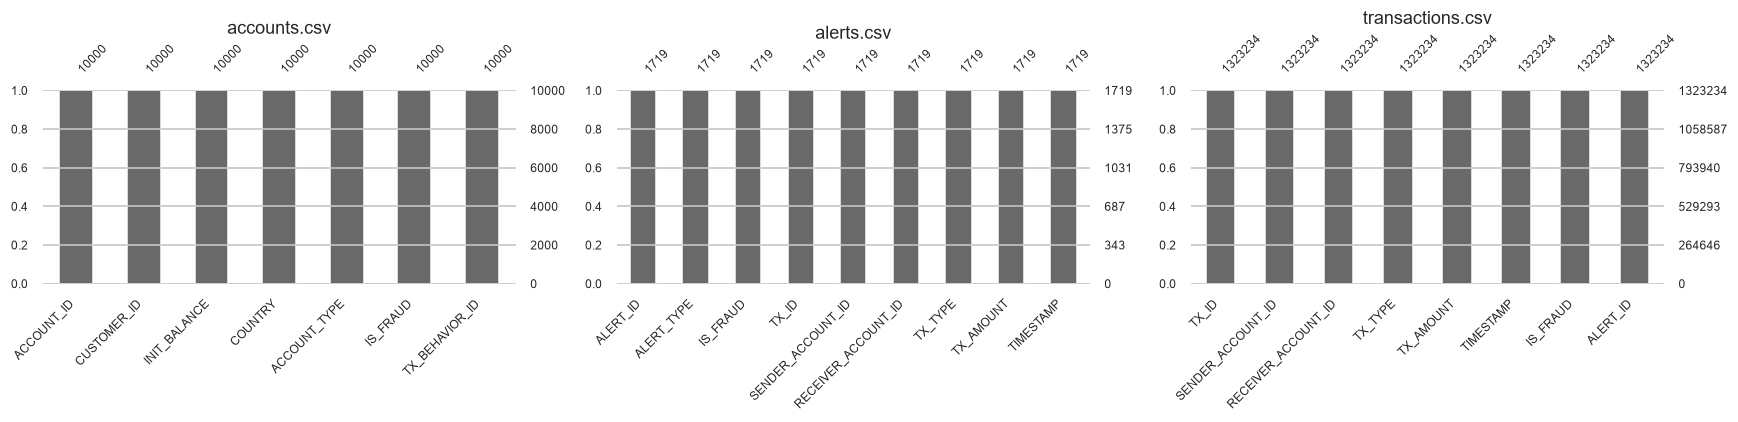

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
msno.bar(accounts, ax=axes[0], fontsize=8)
axes[0].set_title("accounts.csv")
msno.bar(alerts, ax=axes[1], fontsize=8)
axes[1].set_title("alerts.csv")
msno.bar(transactions, ax=axes[2], fontsize=8)
axes[2].set_title("transactions.csv")
plt.tight_layout()
plt.show()


### 3.3 Duplicates

A duplicated `ACCOUNT_ID` or `TX_ID` would indicate a generation or export error and would inflate account-level aggregates (a transaction counted twice distorts totals). Duplicates are checked at the primary-key level, not only for fully identical rows.

In [14]:
dup_accounts = accounts["ACCOUNT_ID"].duplicated().sum()
dup_tx_id = transactions["TX_ID"].duplicated().sum()
dup_alert_rows = alerts.duplicated().sum()

print(f"Duplicate ACCOUNT_ID in accounts.csv: {dup_accounts}")
print(f"Duplicate TX_ID in transactions.csv: {dup_tx_id}")
print(f"Fully duplicated rows in alerts.csv: {dup_alert_rows}")


Duplicate ACCOUNT_ID in accounts.csv: 0
Duplicate TX_ID in transactions.csv: 0
Fully duplicated rows in alerts.csv: 0


### 3.4 Referential integrity across tables

`transactions.csv` references accounts via `SENDER_ACCOUNT_ID` and `RECEIVER_ACCOUNT_ID`. Any ID absent from `accounts.csv` would produce orphan transactions that could not be assigned to any account during feature construction, silently yielding `NaN` values in the join. Each `TX_ID` referenced in `alerts.csv` is likewise verified to exist in `transactions.csv`.

In [15]:
account_ids = set(accounts["ACCOUNT_ID"])
sender_ids = set(transactions["SENDER_ACCOUNT_ID"])
receiver_ids = set(transactions["RECEIVER_ACCOUNT_ID"])

senders_not_in_accounts = sender_ids - account_ids
receivers_not_in_accounts = receiver_ids - account_ids

print(f"SENDER_ACCOUNT_ID in transactions NOT present in accounts.csv: {len(senders_not_in_accounts)}")
print(f"RECEIVER_ACCOUNT_ID in transactions NOT present in accounts.csv: {len(receivers_not_in_accounts)}")

# Accounts never appearing as sender or receiver (no activity -> zero-valued features)
no_activity_as_sender = account_ids - sender_ids
no_activity_as_receiver = account_ids - receiver_ids
print(f"\nAccounts that never send any transaction: {len(no_activity_as_sender)}")
print(f"Accounts that never receive any transaction: {len(no_activity_as_receiver)}")

# TX_ID values in alerts.csv must exist in transactions.csv
tx_ids_in_transactions = set(transactions["TX_ID"])
alert_tx_not_found = set(alerts["TX_ID"]) - tx_ids_in_transactions
print(f"\nTX_ID in alerts.csv NOT found in transactions.csv: {len(alert_tx_not_found)}")


SENDER_ACCOUNT_ID in transactions NOT present in accounts.csv: 0
RECEIVER_ACCOUNT_ID in transactions NOT present in accounts.csv: 0

Accounts that never send any transaction: 1
Accounts that never receive any transaction: 74

TX_ID in alerts.csv NOT found in transactions.csv: 0


**Accounts without activity:** accounts that never send or never receive transactions do not constitute a data error but genuine inactivity within the observed window. **Decision:** they are retained; their activity features will be 0 during feature engineering, which is valid information.

### 3.5 Value ranges and data-quality outliers

This section targets *capture errors* rather than behavioral anomalies (addressed in the bivariate EDA): negative `TX_AMOUNT` values, unexplained negative balances, or `TIMESTAMP` values outside the simulation range.

In [16]:
print("TX_AMOUNT - transactions.csv:")
print(transactions["TX_AMOUNT"].describe())
print(f"\nTransactions with amount <= 0: {(transactions['TX_AMOUNT'] <= 0).sum()}")

print("\nINIT_BALANCE - accounts.csv:")
print(accounts["INIT_BALANCE"].describe())
print(f"\nAccounts with negative initial balance: {(accounts['INIT_BALANCE'] < 0).sum()}")

print(f"\nTIMESTAMP range in transactions.csv: {transactions['TIMESTAMP'].min()} to {transactions['TIMESTAMP'].max()}")
print(f"TIMESTAMP range in alerts.csv: {alerts['TIMESTAMP'].min()} to {alerts['TIMESTAMP'].max()}")

TX_AMOUNT - transactions.csv:
count    1.323234e+06
mean     1.159882e+05
std      1.320091e+06
min      0.000000e+00
25%      2.393000e+01
50%      1.567100e+02
75%      4.400000e+02
max      2.147484e+07
Name: TX_AMOUNT, dtype: float64

Transactions with amount <= 0: 19

INIT_BALANCE - accounts.csv:
count    10000.000000
mean       280.118633
std        137.751335
min        100.000000
25%        162.705000
50%        249.690000
75%        374.222500
max        599.600000
Name: INIT_BALANCE, dtype: float64

Accounts with negative initial balance: 0

TIMESTAMP range in transactions.csv: 0 to 199
TIMESTAMP range in alerts.csv: 0 to 199


### 3.5.1 Investigation of extreme values in `TX_AMOUNT`

Section 3.5 shows `TX_AMOUNT` reaching a maximum of \$21,474,836.47 among non-fraudulent transactions — a figure difficult to reconcile with the maximum initial balance of any account (\$599.60 in `accounts.csv`). The investigation proceeds in three steps: quantify the skew and its source, test whether the maximum corresponds to an identifiable technical defect, and determine whether the affected records are concentrated in one class.

In [17]:
nofraud = transactions.loc[transactions["IS_FRAUD"] == False, "TX_AMOUNT"]

# Step 1: how skewed is the distribution, and where does the skew come from?
total_sum = nofraud.sum()
n = len(nofraud)
mean_val = total_sum / n
median_val = nofraud.median()

top1pct_threshold = nofraud.quantile(0.99)
top1pct_sum = nofraud[nofraud >= top1pct_threshold].sum()
top1pct_n = (nofraud >= top1pct_threshold).sum()

print("--- Step 1: distribution skew ---")
print(f"Mean: ${mean_val:,.2f}   Median: ${median_val:,.2f}")
print(f"The top {top1pct_n/n*100:.2f}% of transactions ({top1pct_n:,} rows) accounts for "
      f"{top1pct_sum/total_sum*100:.1f}% of the total transacted amount.")

# Step 2: is the upper extreme a 32-bit signed integer overflow?
max_val = nofraud.max()
int32_ceiling = 2_147_483_647 / 100
n_at_ceiling = (nofraud == max_val).sum()

print("\n--- Step 2: integer overflow at the ceiling? ---")
print(f"Maximum value: ${max_val:,.2f}   Signed int32 limit (/100): ${int32_ceiling:,.2f}")
print(f"Match: {abs(max_val - int32_ceiling) < 0.01}")
print(f"Transactions pinned exactly at the ceiling: {n_at_ceiling} ({n_at_ceiling/n*100:.3f}% of the file)")

--- Step 1: distribution skew ---
Mean: $116,139.04   Median: $156.97
The top 1.00% of transactions (13,216 rows) accounts for 94.6% of the total transacted amount.

--- Step 2: integer overflow at the ceiling? ---
Maximum value: $21,474,836.47   Signed int32 limit (/100): $21,474,836.47
Match: True
Transactions pinned exactly at the ceiling: 3053 (0.231% of the file)


In [18]:
# Step 3: are extreme amounts concentrated in fraudulent accounts, or evenly spread?
extreme_tx = transactions[transactions["TX_AMOUNT"] > 1_000_000]
accounts_touched = set(extreme_tx["SENDER_ACCOUNT_ID"]) | set(extreme_tx["RECEIVER_ACCOUNT_ID"])

fraud_rate_touched = accounts[accounts["ACCOUNT_ID"].isin(accounts_touched)]["IS_FRAUD"].mean() * 100
fraud_rate_overall = accounts["IS_FRAUD"].mean() * 100

print("--- Step 3: do extreme amounts bias the target toward one class? ---")
print(f"Accounts touching amounts > $1,000,000: {len(accounts_touched):,} of 10,000 "
      f"({len(accounts_touched)/10000*100:.1f}%)")
print(f"Fraud rate among those accounts: {fraud_rate_touched:.2f}%")
print(f"Overall fraud rate (baseline):    {fraud_rate_overall:.2f}%")

# Impact on aggregate variance (relevant to scaling in Logistic Regression)
out_with = transactions.groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"].sum()
out_without = transactions[transactions["TX_AMOUNT"] <= 1_000_000].groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"].sum()

print(f"\nStd. dev. of out_amount_total WITH extreme amounts: ${out_with.std():,.2f}")
print(f"Std. dev. of out_amount_total WITHOUT extreme amounts: ${out_without.std():,.2f}")

--- Step 3: do extreme amounts bias the target toward one class? ---
Accounts touching amounts > $1,000,000: 7,339 of 10,000 (73.4%)
Fraud rate among those accounts: 18.60%
Overall fraud rate (baseline):    16.85%

Std. dev. of out_amount_total WITH extreme amounts: $35,622,090.34
Std. dev. of out_amount_total WITHOUT extreme amounts: $971,264.60


**Conclusion and cleaning decision:**

The distribution is severely skewed: the top 1% of transactions accounts for roughly 95% of the total transacted amount, which explains why the mean (\$116,139) bears no resemblance to a typical transaction (median: \$156.97, consistent with the observed account balances). Within that 1%, the upper extreme carries an identifiable defect: the maximum value matches exactly the signed 32-bit integer limit (2³¹ − 1 ÷ 100), with 3,053 transactions (0.23% of the file) pinned precisely at that ceiling. Reinforcing this conclusion, 73.4% of accounts (7,339 of 10,000) touch at least one transaction above \$1,000,000 — an implausible proportion for individual accounts whose maximum initial balance is \$599.60.

**Does this bias the model toward one class?** No. The fraud rate among accounts touching extreme amounts (18.60%) is nearly identical to the baseline (16.85%), and none of the 1,719 flagged transactions exceeds \$1,000. The defect is spread almost evenly across fraudulent and legitimate accounts; capping these values therefore removes no information that distinguishes the class of interest.

**What the defect does distort is feature scale, not class balance.** The standard deviation of `out_amount_total` drops from \$35,622,090 to \$971,265 once these transactions are excluded — a 35-fold reduction. This is critical for Logistic Regression: standardizing features against such an inflated standard deviation compresses the values of the remaining 99% of accounts toward zero, eroding their discriminative power. The risk for XGBoost is lower but non-zero: splits driven by a handful of extreme accounts do not generalize.

**Decision:** account-level amount aggregates will use winsorization (capping the upper tail at a suitable percentile, e.g. p99) rather than treating the values as missing — with 73.4% of accounts affected, full censoring would be prohibitively costly in information loss. A counter feature (`n_extreme_value_tx`) will be added to preserve the signal that an account touched at least one transaction above the threshold, decoupled from the amount itself.

### 3.6 Zero-variance (constant) columns

A column holding a single value carries no discriminative power for any model. These are identified explicitly so they can be discarded as a documented decision rather than an oversight.

In [19]:
nunique = accounts.nunique()
print(nunique)
print("\nColumns with a single unique value (candidates for removal):")
print(nunique[nunique == 1])


ACCOUNT_ID        10000
CUSTOMER_ID       10000
INIT_BALANCE       8818
COUNTRY               1
ACCOUNT_TYPE          1
IS_FRAUD              2
TX_BEHAVIOR_ID        5
dtype: int64

Columns with a single unique value (candidates for removal):
COUNTRY         1
ACCOUNT_TYPE    1
dtype: int64


**Decision:** `COUNTRY` (single value: `US`) and `ACCOUNT_TYPE` (single value: `I`) have zero variance across the 10,000 accounts and will be discarded as features. They are retained in the DataFrame to preserve traceability to the original dataset.

### 3.7 Consistency of the `IS_FRAUD` label across files

The fraud label appears in three places at different levels of granularity:

- `accounts.IS_FRAUD` → account level (the final target).
- `alerts.IS_FRAUD` → always `True` (the file contains only positive cases).
- `transactions.IS_FRAUD` → individual transaction level.

If an account were flagged `IS_FRAUD = True` in `accounts.csv` yet never appeared as sender or receiver in `alerts.csv` — or, more critically, if an account appearing in `alerts.csv` were left unflagged in `accounts.csv` — the direct use of `accounts.IS_FRAUD` as the target would be compromised. Both directions are validated below.

In [20]:
fraud_accounts = set(accounts.loc[accounts["IS_FRAUD"] == True, "ACCOUNT_ID"])
accounts_in_alerts = set(alerts["SENDER_ACCOUNT_ID"]) | set(alerts["RECEIVER_ACCOUNT_ID"])

fraud_acc_not_in_alerts = fraud_accounts - accounts_in_alerts
alert_acc_not_flagged = accounts_in_alerts - fraud_accounts

print(f"Accounts flagged IS_FRAUD=True in accounts.csv: {len(fraud_accounts)}")
print(f"Accounts appearing in alerts.csv (sender or receiver): {len(accounts_in_alerts)}")
print(f"\nfraud=True accounts NEVER appearing in alerts.csv: {len(fraud_acc_not_in_alerts)}")
print(f"Accounts in alerts.csv NOT flagged fraud=True in accounts.csv: {len(alert_acc_not_flagged)}")


Accounts flagged IS_FRAUD=True in accounts.csv: 1685
Accounts appearing in alerts.csv (sender or receiver): 1639

fraud=True accounts NEVER appearing in alerts.csv: 46
Accounts in alerts.csv NOT flagged fraud=True in accounts.csv: 0


**Conclusion:** the consistency check between `accounts.csv` and `alerts.csv` confirms that **no account with direct transactional evidence of participating in a laundering pattern (present in `alerts.csv`) was left unflagged in `accounts.csv`** — the target omits no case backed by confirmed evidence.

46 of the 1,685 flagged accounts (2.7%) do not appear in any transaction within `alerts.csv`. This is interpreted as a limitation in the scope of the delivered extract — plausibly because segments of those patterns were executed through channels not included (e.g. cash) — rather than as label corruption.

**Decision:** `accounts.IS_FRAUD` is retained as the target variable, without redefinition.

## 4. Univariate EDA

### 4.1 Target class balance (`IS_FRAUD`)

Class imbalance is the single most consequential design constraint of the project: it determines whether class weighting is required, which evaluation metrics are appropriate (PR-AUC vs. ROC-AUC), and how the train/test split must be performed.

IS_FRAUD
False    8315
True     1685
Name: count, dtype: int64

IS_FRAUD
False    83.15
True     16.85
Name: proportion, dtype: float64


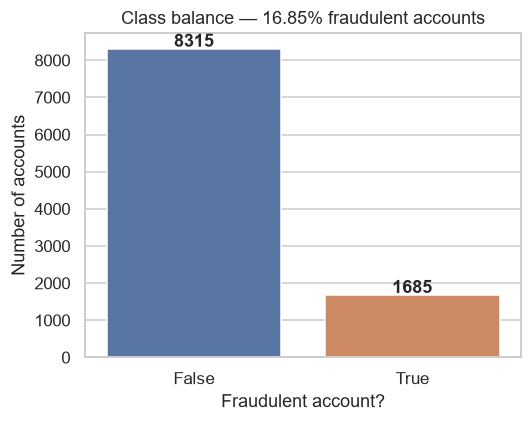

In [21]:
fraud_counts = accounts["IS_FRAUD"].value_counts()
fraud_pct = accounts["IS_FRAUD"].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=accounts, x="IS_FRAUD", hue="IS_FRAUD", legend=False, ax=ax)
ax.set_title(f"Class balance — {fraud_pct[True]:.2f}% fraudulent accounts")
ax.set_xlabel("Fraudulent account?")
ax.set_ylabel("Number of accounts")
for i, v in enumerate(fraud_counts):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** 1,685 of 10,000 accounts are flagged (**16.85%**), a moderate imbalance. In a real AML environment the rate of genuinely suspicious cases is typically well below 1%. This is declared as a dataset limitation: metrics obtained on this data likely overstate the performance the same approach would achieve in production.

### 4.2 Distribution of initial balance (`INIT_BALANCE`)

`INIT_BALANCE` does not separate the classes on its own (Section 2.1.1). It is examined here for two reasons: it exposes the discrete band structure that `TX_BEHAVIOR_ID` encodes, and it establishes the scale required to build ratio-based features (e.g. total amount moved relative to initial balance), a standard AML signal.

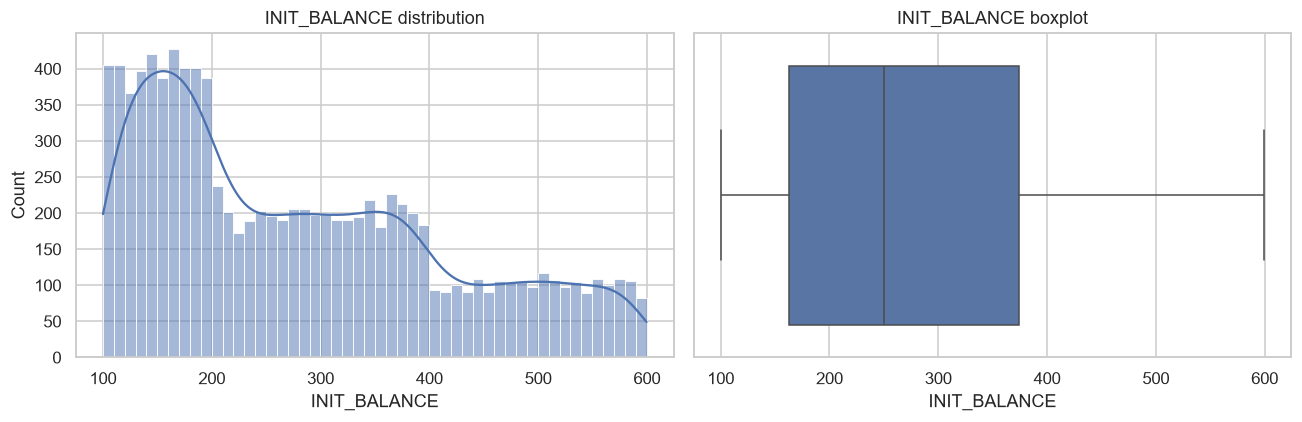

count    10000.000000
mean       280.118633
std        137.751335
min        100.000000
25%        162.705000
50%        249.690000
75%        374.222500
max        599.600000
Name: INIT_BALANCE, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(accounts["INIT_BALANCE"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("INIT_BALANCE distribution")
sns.boxplot(x=accounts["INIT_BALANCE"], ax=axes[1])
axes[1].set_title("INIT_BALANCE boxplot")
plt.tight_layout()
plt.show()

print(accounts["INIT_BALANCE"].describe())


### 4.3 Distribution of transaction amounts (`TX_AMOUNT`)

The skew of this variable is analyzed in detail in Section 3.5.1. It is visualized here: the histogram graphically confirms the finding and demonstrates why a logarithmic scale is indispensable — on a linear scale the entire distribution collapses into a single bar near zero.

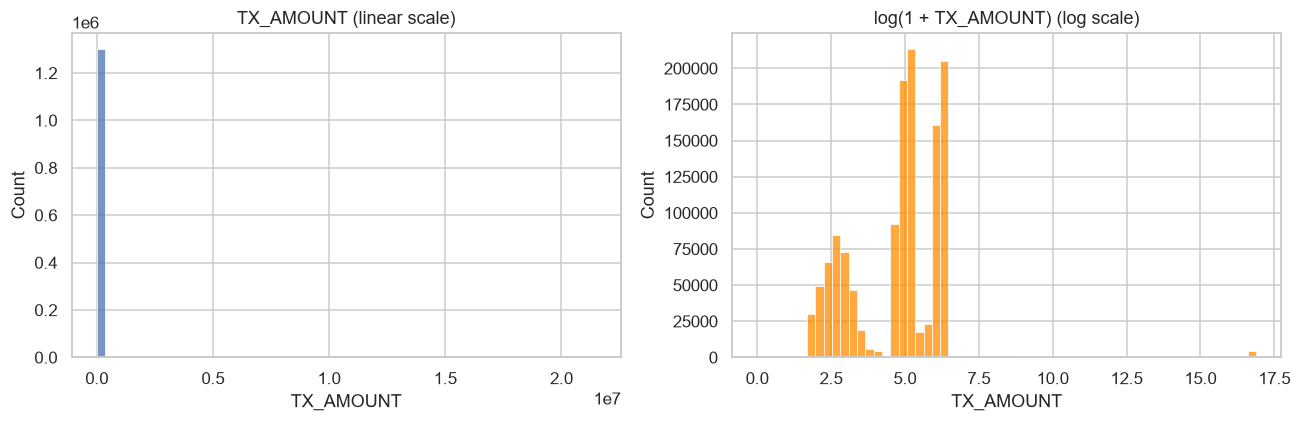

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(transactions["TX_AMOUNT"], bins=60, ax=axes[0])
axes[0].set_title("TX_AMOUNT (linear scale)")

sns.histplot(np.log1p(transactions["TX_AMOUNT"]), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("log(1 + TX_AMOUNT) (log scale)")
plt.tight_layout()
plt.show()

### 4.4 Alert typologies (`ALERT_TYPE`)

Identifying which typologies exist determines which patterns feature engineering must capture. The dataset contains only two (`cycle` and `fan_in`), which narrows the design of network features.

**Unit of count:** this chart counts **alert groups** (unique `ALERT_ID`), not transactions or accounts. An alert group is one complete laundering scheme: a cycle formed by 5 transactions across 5 accounts counts as **1**. The dataset operates at three distinct levels:

| Level | Count | Represents |
|---|---|---|
| Flagged transactions | 1,719 | each individual suspicious transfer |
| **Alert groups** (this chart) | **391** | each complete scheme/pattern |
| Fraudulent accounts | 1,685 | each account involved |

The 391 schemes, averaging ~4.4 transactions each, produce the 1,719 flagged transactions, which in turn touch 1,639 distinct accounts (consistent with Section 3.7). The near-even split between `cycle` (192) and `fan_in` (199) implies that feature engineering must capture both typologies with equal weight.

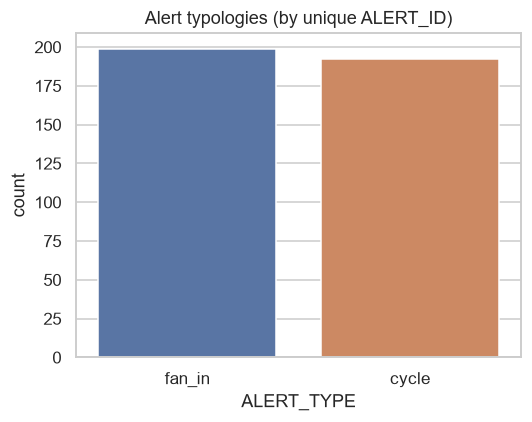

ALERT_TYPE
fan_in    199
cycle     192
Name: count, dtype: int64


In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=alerts.drop_duplicates("ALERT_ID"), x="ALERT_TYPE", hue="ALERT_TYPE", legend=False, ax=ax)
ax.set_title("Alert typologies (by unique ALERT_ID)")
plt.tight_layout()
plt.show()

print(alerts.drop_duplicates("ALERT_ID")["ALERT_TYPE"].value_counts())

### 4.5 Transaction activity over time

Verifies whether transaction volume is stable across the 200 timesteps or exhibits spikes indicating anomalous periods or interruptions in data capture.

**Methodological note:** the series of fraudulent transactions per timestep is not plotted. With a mean of 8.6 flagged transactions per timestep (range 1–17, coefficient of variation 0.39 versus 0.04 for the total series), its fluctuations correspond largely to statistical noise inherent to small counts and could be misread as genuine temporal concentration. The relevant finding is documented in Section 2.1.2: alerts are distributed almost uniformly across the window (`TIMESTAMP` mean 100.56 over a 0–199 range).

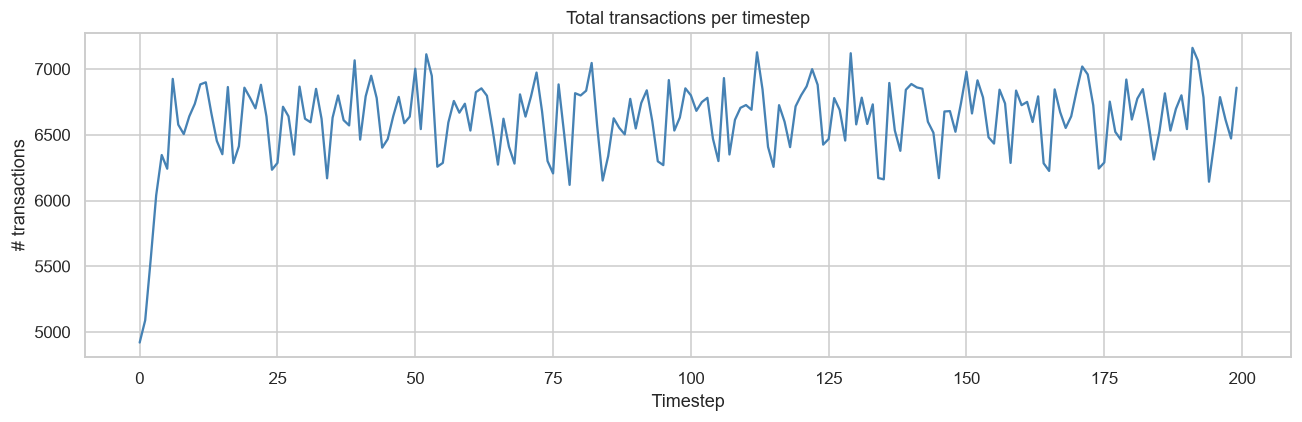

Transactions per timestep — mean: 6616, std: 296, range: 4920-7161


In [25]:
tx_per_timestep = transactions.groupby("TIMESTAMP").size()

fig, ax = plt.subplots(figsize=(12, 4))
tx_per_timestep.plot(ax=ax, color="steelblue")
ax.set_title("Total transactions per timestep")
ax.set_ylabel("# transactions")
ax.set_xlabel("Timestep")
plt.tight_layout()
plt.show()

print(f"Transactions per timestep — mean: {tx_per_timestep.mean():.0f}, "
      f"std: {tx_per_timestep.std():.0f}, range: {tx_per_timestep.min()}-{tx_per_timestep.max()}")

## 5. Bivariate EDA — relationship of variables with `IS_FRAUD`

### 5.1 Fraud rate by `TX_BEHAVIOR_ID`

`IS_FRAUD` is boolean, so its group mean equals the proportion of `True` values — i.e. the percentage of fraudulent accounts within each behavior profile.

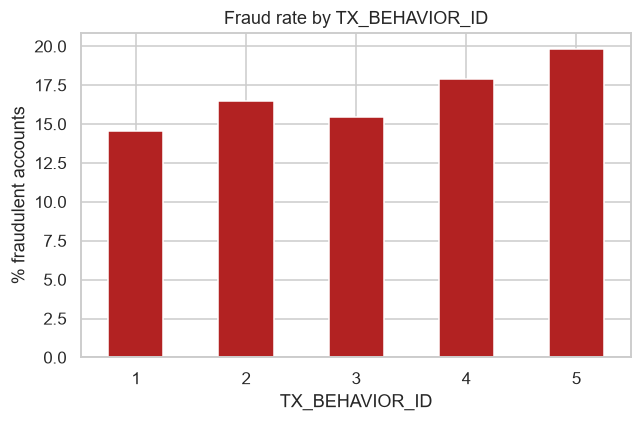

TX_BEHAVIOR_ID
1    14.55
2    16.50
3    15.45
4    17.90
5    19.85
Name: IS_FRAUD, dtype: float64


In [26]:
fraud_rate_by_behavior = accounts.groupby("TX_BEHAVIOR_ID")["IS_FRAUD"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
fraud_rate_by_behavior.plot(kind="bar", ax=ax, color="firebrick")
ax.set_ylabel("% fraudulent accounts")
ax.set_title("Fraud rate by TX_BEHAVIOR_ID")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print(fraud_rate_by_behavior.round(2))

### 5.2 Preliminary account-level aggregation (in-degree, out-degree, amounts)

The aggregations in this section are exploratory; formal feature construction takes place in the feature engineering notebook.

**Rationale for these variables:** both typologies present are graph patterns. `fan_in` implies an abnormally high in-degree (multiple senders converging on one receiving account); `cycle` implies that flow returns to accounts with which the node has already interacted. In-degree and out-degree are therefore the variables with the highest a priori likelihood of separating the classes.

In [27]:
out_stats = transactions.groupby("SENDER_ACCOUNT_ID").agg(
    out_degree=("TX_ID", "count"),
    out_amount_total=("TX_AMOUNT", "sum"),
).rename_axis("ACCOUNT_ID")

in_stats = transactions.groupby("RECEIVER_ACCOUNT_ID").agg(
    in_degree=("TX_ID", "count"),
    in_amount_total=("TX_AMOUNT", "sum"),
).rename_axis("ACCOUNT_ID")

eda_features = accounts.set_index("ACCOUNT_ID")[["IS_FRAUD", "TX_BEHAVIOR_ID"]].join(
    [out_stats, in_stats], how="left"
).fillna(0)

eda_features.head()

,IS_FRAUD,TX_BEHAVIOR_ID,out_degree,out_amount_total,in_degree,in_amount_total
ACCOUNT_ID,,,,,,
0,False,1,0.0,0.00,0.0,0.00
1,False,1,24.0,4219.20,0.0,0.00
2,False,1,18.0,2556.90,0.0,0.00
3,False,1,19.0,2391.72,23.0,313.49
4,False,1,23.0,3475.99,0.0,0.00


### 5.3 In-degree / out-degree distribution by fraud status

**Logarithmic scale:** in-degree spans several orders of magnitude (from single digits up to 4,843). On a linear scale the central 50% of accounts would be compressed into an indistinguishable band against the axis, with the visual space devoted to a handful of extreme accounts. A log scale expands the region where the bulk of the data resides, allowing medians and dispersion to be compared across classes.

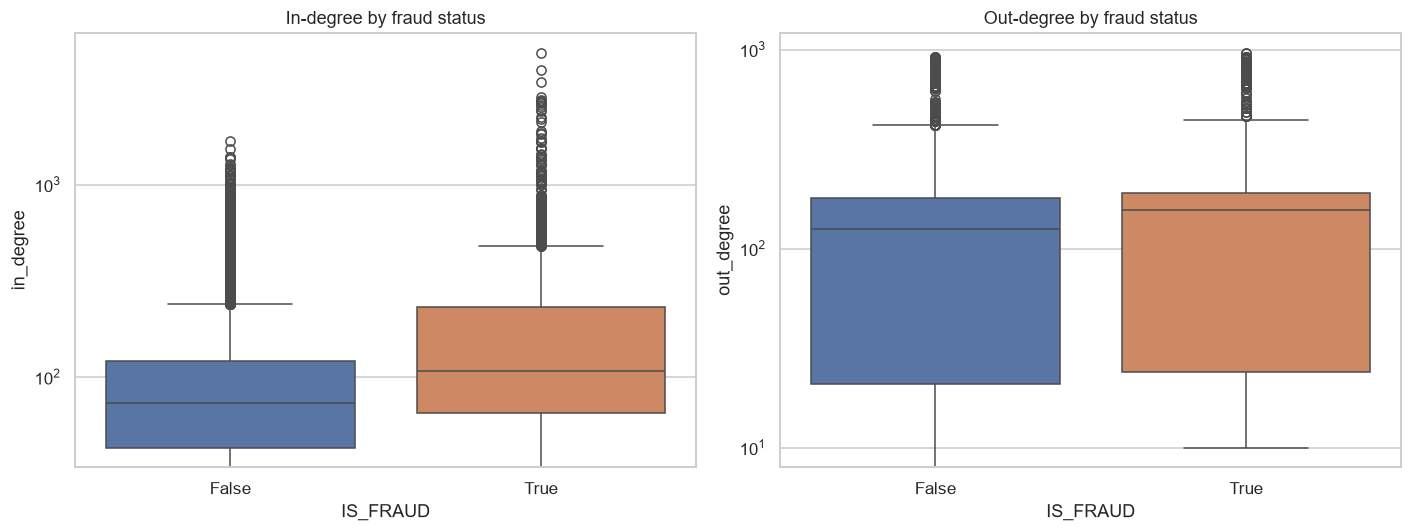

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=eda_features, x="IS_FRAUD", y="in_degree", hue="IS_FRAUD", legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("In-degree by fraud status")

sns.boxplot(data=eda_features, x="IS_FRAUD", y="out_degree", hue="IS_FRAUD", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Out-degree by fraud status")

plt.tight_layout()
plt.show()

### 5.4 Statistical test: significance of the observed differences

**Mann-Whitney U rather than a t-test:** the t-test compares means and assumes normality. The variables analyzed are heavy-tailed and non-normal, and their means are distorted by extreme values (documented in Section 3.5.1). Mann-Whitney U is the non-parametric alternative: it compares ranks (ordinal positions) rather than absolute values, so each observation — however extreme — contributes a single rank and cannot dominate the result. It is the appropriate test for financial and count variables with this distribution.

**Scope:** the test is univariate — it evaluates each variable in isolation. It serves to prioritize feature engineering, not to discard features: a variable with weak standalone evidence may prove predictive in combination with others. Definitive assessment rests with the model (feature importance / SHAP).

In [29]:
for col in ["in_degree", "out_degree", "in_amount_total", "out_amount_total"]:
    fraud_vals = eda_features.loc[eda_features["IS_FRAUD"] == True, col]
    legit_vals = eda_features.loc[eda_features["IS_FRAUD"] == False, col]
    stat, p_value = stats.mannwhitneyu(fraud_vals, legit_vals, alternative="two-sided")
    signif = "significant" if p_value < 0.05 else "NOT significant"
    print(f"{col:20s} -> p-value = {p_value:.2e}  ({signif} at 5%)")

in_degree            -> p-value = 6.26e-80  (significant at 5%)
out_degree           -> p-value = 9.80e-21  (significant at 5%)
in_amount_total      -> p-value = 1.41e-54  (significant at 5%)
out_amount_total     -> p-value = 4.34e-04  (significant at 5%)


### 5.5 In-degree vs. out-degree, colored by fraud status

A two-dimensional scatter reveals whether the combination of both variables separates the classes better than either alone, which anticipates whether a linear model (Logistic Regression) can trace an adequate decision boundary or whether a non-linear model (XGBoost) will be required to capture the interaction.

**Visual limitation:** with 8,315 legitimate accounts against 1,685 fraudulent ones, the majority class partially occludes the minority class in dense regions. Only the low-density regions (upper extremes) are reliably interpretable.

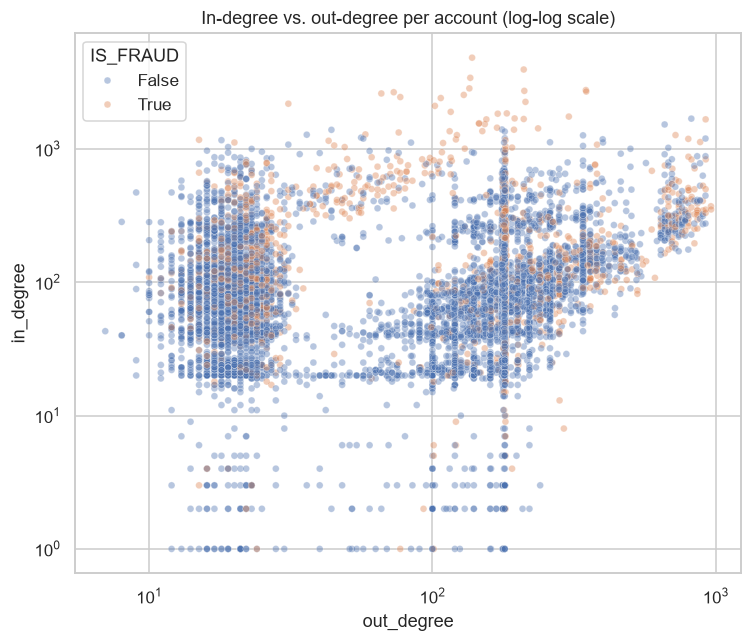

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=eda_features, x="out_degree", y="in_degree",
    hue="IS_FRAUD", alpha=0.4, s=20, ax=ax
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("In-degree vs. out-degree per account (log-log scale)")
plt.tight_layout()
plt.show()

## 6. Network pattern visualization and verification (`cycle` and `fan_in`)

The typologies present are graph patterns. This section reconstructs real examples of each using `networkx` and formally verifies that the labeled groups exhibit the topology they declare.

### 6.1 `cycle` typology

A `cycle` is a layering pattern: funds traverse a chain of accounts and return to the origin, obscuring the provenance of the money.

 SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID  TX_AMOUNT  TIMESTAMP
              9721                 9057      17.17         90
              1670                 9721      17.17         91
              9057                 9118      17.17         92
              9118                 9989      17.17         96
              9989                 1670      17.17         97


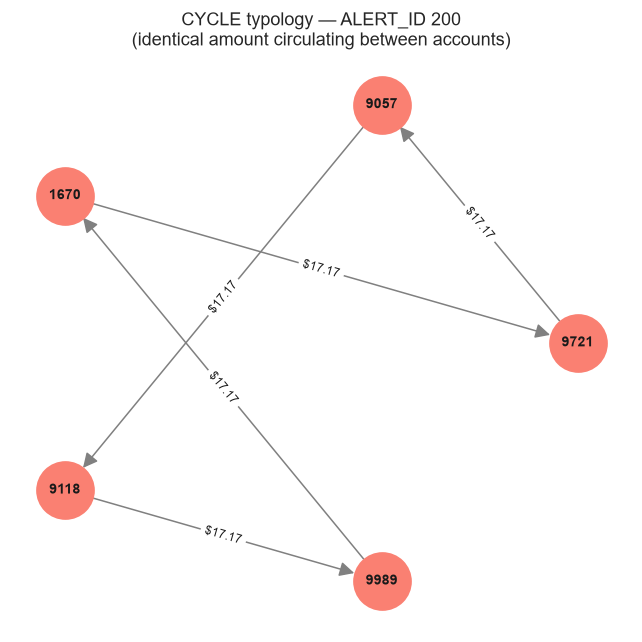

In [35]:
cycle_alert_id = 200

cycle_tx = alerts[alerts["ALERT_ID"] == cycle_alert_id].sort_values("TIMESTAMP")
print(cycle_tx[["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID", "TX_AMOUNT", "TIMESTAMP"]].to_string(index=False))

G_cycle = nx.DiGraph()
for _, row in cycle_tx.iterrows():
    G_cycle.add_edge(row["SENDER_ACCOUNT_ID"], row["RECEIVER_ACCOUNT_ID"], amount=row["TX_AMOUNT"])

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.circular_layout(G_cycle)
nx.draw(
    G_cycle, pos, ax=ax, with_labels=True, node_color="salmon", node_size=1400,
    font_size=9, font_weight="bold", arrowsize=20, edge_color="gray"
)
edge_labels = {(u, v): f"${d['amount']:.2f}" for u, v, d in G_cycle.edges(data=True)}
nx.draw_networkx_edge_labels(G_cycle, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title(f"CYCLE typology — ALERT_ID {cycle_alert_id}\n(identical amount circulating between accounts)")
plt.tight_layout()
plt.show()

### 6.2 `fan_in` typology

A `fan_in` corresponds to smurfing/structuring: multiple sending accounts transfer fractioned amounts into a single receiving account that concentrates the funds.

 SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID  TX_AMOUNT  TIMESTAMP
              9810                 9997       4.20        163
              9332                 9997       4.83        165
              2962                 9997       4.80        167
              8181                 9997       4.21        169


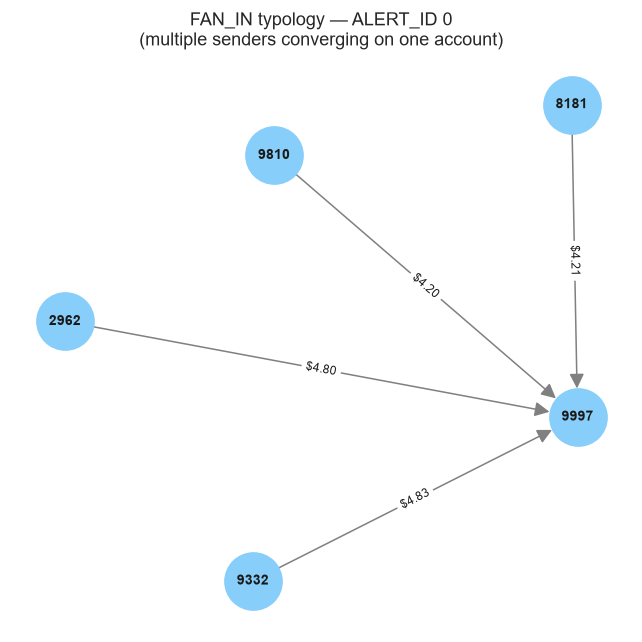

In [32]:
fanin_alert_id = 0

fanin_tx = alerts[alerts["ALERT_ID"] == fanin_alert_id].sort_values("TIMESTAMP")
print(fanin_tx[["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID", "TX_AMOUNT", "TIMESTAMP"]].to_string(index=False))

G_fanin = nx.DiGraph()
for _, row in fanin_tx.iterrows():
    G_fanin.add_edge(row["SENDER_ACCOUNT_ID"], row["RECEIVER_ACCOUNT_ID"], amount=row["TX_AMOUNT"])

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(G_fanin, seed=42)
nx.draw(
    G_fanin, pos, ax=ax, with_labels=True, node_color="lightskyblue", node_size=1400,
    font_size=9, font_weight="bold", arrowsize=20, edge_color="gray"
)
edge_labels = {(u, v): f"${d['amount']:.2f}" for u, v, d in G_fanin.edges(data=True)}
nx.draw_networkx_edge_labels(G_fanin, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title(f"FAN_IN typology — ALERT_ID {fanin_alert_id}\n(multiple senders converging on one account)")
plt.tight_layout()
plt.show()

### 6.3 Topological integrity verification of the alerts

Not every group labeled `cycle` exhibits a closed cycle when its graph is reconstructed. The phenomenon is quantified and its cause determined, since a label inconsistent with its declared topology would directly affect the design of network features.

In [33]:
cycle_groups = alerts[alerts["ALERT_TYPE"] == "cycle"]

closed, incomplete_ids = 0, []
for aid, g in cycle_groups.groupby("ALERT_ID"):
    G = nx.DiGraph()
    for _, r in g.iterrows():
        G.add_edge(r["SENDER_ACCOUNT_ID"], r["RECEIVER_ACCOUNT_ID"])
    if list(nx.simple_cycles(G)):
        closed += 1
    else:
        incomplete_ids.append(aid)

n_total = cycle_groups["ALERT_ID"].nunique()
print(f"Total 'cycle' groups: {n_total}")
print(f"  With a verified closed cycle: {closed} ({closed/n_total*100:.1f}%)")
print(f"  Without a closed cycle (fragment): {len(incomplete_ids)} ({len(incomplete_ids)/n_total*100:.1f}%)")

# Do the fragments cluster at the edges of the observation window?
print("\nIncomplete 'cycle' groups — size and temporal location:")
for aid in incomplete_ids:
    g = cycle_groups[cycle_groups["ALERT_ID"] == aid]
    ts = sorted(g["TIMESTAMP"].tolist())
    print(f"  ALERT_ID {aid}: {len(g)} tx, timestamps {ts}")

print(f"\nObservation window: timesteps 0-{transactions['TIMESTAMP'].max()}")

Total 'cycle' groups: 192
  With a verified closed cycle: 183 (95.3%)
  Without a closed cycle (fragment): 9 (4.7%)

Incomplete 'cycle' groups — size and temporal location:
  ALERT_ID 207: 3 tx, timestamps [195, 196, 196]
  ALERT_ID 222: 2 tx, timestamps [194, 199]
  ALERT_ID 231: 1 tx, timestamps [198]
  ALERT_ID 267: 4 tx, timestamps [4, 4, 7, 12]
  ALERT_ID 272: 1 tx, timestamps [198]
  ALERT_ID 294: 2 tx, timestamps [198, 199]
  ALERT_ID 321: 2 tx, timestamps [195, 198]
  ALERT_ID 323: 4 tx, timestamps [8, 8, 9, 10]
  ALERT_ID 381: 2 tx, timestamps [194, 196]

Observation window: timesteps 0-199


**Finding — observation window censoring:**

183 of 192 `cycle` groups (95.3%) form a verifiable closed cycle, and all of them contain exactly 5 transactions. The remaining 9 groups (4.7%) contain between 1 and 4 transactions and do not close.

The cause is temporal position: 7 of the 9 fragments occur between timesteps 194–199 (the trailing edge of a window ending at 199), and the remaining 2 between timesteps 4–12 (the leading edge). The same pattern appears in `fan_in`, with 9 incomplete groups clustered at the same boundaries.

**Interpretation:** this is neither a labeling error nor noise. The patterns were mid-execution when the capture window closed (or already underway when it opened), so only a fragment of the scheme was recorded. The label is correct — those transactions do belong to a laundering scheme; what is missing is the remainder of the scheme, outside the observed period.

**Operational relevance:** this phenomenon is equivalent to what occurs in a production AML system, where any finite analysis window truncates the schemes that cross it. A model trained on this window must be able to flag accounts from partial evidence, not only from complete patterns — reinforcing the need for features that capture individual behavioral anomalies (flow concentration, in/out imbalance) rather than relying solely on the presence of a complete closed topology.

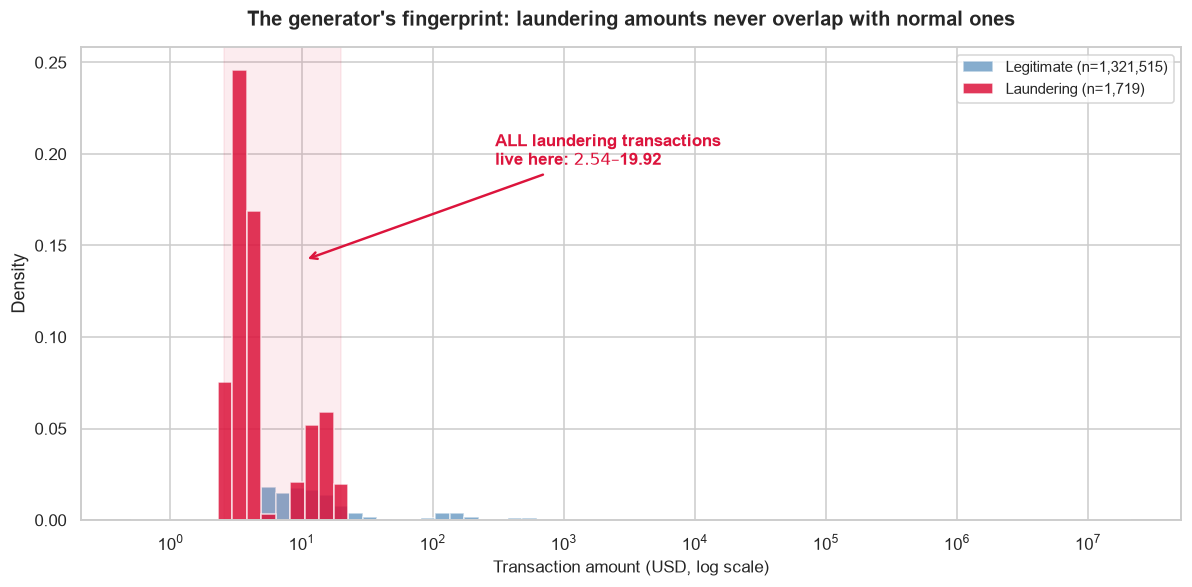

In [36]:
fraud = transactions.loc[transactions["IS_FRAUD"] == True, "TX_AMOUNT"]
legit = transactions.loc[transactions["IS_FRAUD"] == False, "TX_AMOUNT"]

fig, ax = plt.subplots(figsize=(11, 5.5))
bins = np.logspace(np.log10(0.5), np.log10(legit.max()), 70)

ax.hist(legit, bins=bins, alpha=0.65, density=True,
        label=f"Legitimate (n={len(legit):,})", color="steelblue")
ax.hist(fraud, bins=bins, alpha=0.85, density=True,
        label=f"Laundering (n={len(fraud):,})", color="crimson")

ax.set_xscale("log")
ax.axvspan(fraud.min(), fraud.max(), color="crimson", alpha=0.08)
ax.annotate(
    f"ALL laundering transactions\nlive here: ${fraud.min():.2f} – ${fraud.max():.2f}",
    xy=(fraud.median(), ax.get_ylim()[1] * 0.55),
    xytext=(300, ax.get_ylim()[1] * 0.75),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.6),
    fontsize=11, color="crimson", fontweight="bold", ha="left",
)

ax.set_xlabel("Transaction amount (USD, log scale)", fontsize=11)
ax.set_ylabel("Density")
ax.set_title("The generator's fingerprint: laundering amounts never overlap with normal ones",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("slide11_amount_artifact.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary of findings and decisions

### 7.1 Data quality verification

| Check | Result |
|---|---|
| Missing values | 0 across all three files |
| Duplicates in primary keys | 0 (`ACCOUNT_ID`, `TX_ID`) |
| Referential integrity | 0 orphan IDs: every `SENDER_ACCOUNT_ID` / `RECEIVER_ACCOUNT_ID` exists in `accounts.csv` |
| `TX_ID` sequential | 1 to 1,323,234 with no gaps — file complete |
| Negative amounts and balances | 0 |
| Accounts without activity | 1 never sends, 74 never receive (genuine inactivity, not error) |
| `IS_FRAUD` consistency | 0 accounts with evidence in `alerts.csv` left unflagged in `accounts.csv` |

### 7.2 Dataset structure

| Element | Value |
|---|---|
| Accounts | 10,000 |
| Transactions | 1,323,234 (all `TRANSFER`) |
| Suspicious/SAR accounts | 1,685 (**16.85%**) |
| Flagged transactions | 1,719 (0.13%) |
| Alert groups | 391 (`cycle`: 192, `fan_in`: 199) |
| Time window | 200 timesteps (0–199) |

### 7.3 Principal findings

**1. Moderate class imbalance (16.85%).** Not representative of a real AML environment, where the rate of suspicious cases typically falls below 1%. Metrics obtained on this data likely overstate production performance. Mitigation: `class_weight='balanced'` for Logistic Regression and `scale_pos_weight` for XGBoost; PR-AUC reported alongside ROC-AUC.

**2. Data defect in `TX_AMOUNT` — integer overflow.** The maximum value (\$21,474,836.47) matches exactly the signed 32-bit integer limit divided by 100. 3,053 transactions (0.23%) are pinned at that ceiling, and 73.4% of accounts (7,339) touch at least one transaction above \$1,000,000 — an implausible magnitude against a maximum initial balance of \$599.60. The resulting distribution is severely skewed: the top 1% accounts for 94.6% of the total transacted amount, driving the mean to \$116,139 against a median of \$156.97.

**3. The defect does not bias the target.** The fraud rate among accounts touching extreme amounts (18.60%) is essentially equal to the baseline (16.85%), and none of the 1,719 flagged transactions exceeds \$1,000. The problem affects feature scale, not class balance.

**4. `IS_FRAUD` validated as the target.** No account with direct transactional evidence was left unflagged. 46 flagged accounts (2.7%) lack evidence in `alerts.csv` — a limitation of the extract's scope, not target corruption.

**5. In-degree is the most discriminative single variable.** Mann-Whitney U on the preliminary aggregations:

| Variable | p-value |
|---|---|
| `in_degree` | 6.26e-80 |
| `in_amount_total` | 1.41e-54 |
| `out_degree` | 9.80e-21 |
| `out_amount_total` | 4.34e-04 |

All four are significant at the 5% level. The pattern is consistent with the typologies present: **inbound** flow variables dominate outbound ones, as expected given that `fan_in` concentrates flow on the receiving account. Effect size, however, is limited — the boxplots show substantial overlap between classes, indicating that raw count features are insufficient on their own.

**6. `TX_BEHAVIOR_ID` encodes structure.** It determines the `INIT_BALANCE` range (values 1 and 4 → \$100–200; 2 and 5 → \$200–400; 3 → \$400–600) and exhibits distinct fraud propensities between profiles sharing a balance range (14.55% for profile 1 vs. 17.90% for profile 4). It is informative but constitutes an artifact of the generation process: a real account does not arrive pre-labeled with its behavior pattern. Its use must be declared as a generalization limitation.

**7. Observation window censoring.** 9 of 192 `cycle` groups (4.7%) and 9 of 199 `fan_in` groups do not exhibit their complete topology. All are fragments located at the temporal edges of the window (timesteps 194–199 or 4–12). This is not a labeling error: they are schemes truncated by the start or end of the captured period — a phenomenon equivalent to that of any finite analysis window in production.

### 7.4 Dataset limitations

- **Single channel:** all transactions are `TRANSFER`. No cash deposits or withdrawals, both material channels in real AML.
- **No geographic or account-type dimension:** `COUNTRY` (`US`) and `ACCOUNT_TYPE` (`I`) are constant. No cross-border risk signal and no corporate/institutional behavior.
- **1:1 customer-account relationship:** `CUSTOMER_ID` is a deterministic function of `ACCOUNT_ID`. No customers hold multiple accounts, a common real-world scenario.
- **Only two typologies:** `cycle` and `fan_in`. Patterns such as `fan_out`, `scatter-gather` or `stack` are absent.
- **Uniform pattern geometry:** complete `cycle` groups invariably contain 5 transactions and `fan_in` groups 4 — a regularity not observed in real schemes.
- **Class imbalance not representative:** 16.85% is far above the sub-1% rates typical of production AML.
- **Amount generation defect:** the 32-bit integer overflow documented in Section 3.5.1.

### 7.5 Decisions carried into feature engineering

1. **Target:** `accounts.IS_FRAUD`, without redefinition.
2. **Discarded columns:** `COUNTRY`, `ACCOUNT_TYPE` (zero variance) and `CUSTOMER_ID` (redundant with `ACCOUNT_ID`).
3. **`TX_AMOUNT` treatment:** winsorization of the upper tail (p99) prior to aggregation. Full censoring as missing data is not applied, since 73.4% of accounts would be affected. A counter feature (`n_extreme_value_tx`) will preserve the occurrence signal without letting the amount distort the aggregates.
4. **Leakage prevention:** the winsorization threshold will be computed exclusively on the training set and applied as a fixed value to both train and test.
5. **Features excluded for direct leakage:** `ALERT_ID` and transaction-level `IS_FRAUD`.
6. **Feature priority:** given the overlap observed in raw count variables, effort will be directed toward structural network features — distinct counterparties (not merely transaction counts), in/out flow ratio, reciprocity, and temporal concentration.

## 8. Export of verified data

`accounts.csv` is exported with verified types as a documented starting point for the feature engineering notebook.

In [34]:
import os

os.makedirs("data_processed", exist_ok=True)

accounts_verified = accounts.copy()
accounts_verified["TX_BEHAVIOR_ID"] = accounts_verified["TX_BEHAVIOR_ID"].astype("category")

accounts_verified.to_csv("data_processed/accounts_verified.csv", index=False)
print("Saved: data_processed/accounts_verified.csv")
print(accounts_verified.dtypes)

Saved: data_processed/accounts_verified.csv
ACCOUNT_ID           int64
CUSTOMER_ID            str
INIT_BALANCE       float64
COUNTRY                str
ACCOUNT_TYPE           str
IS_FRAUD              bool
TX_BEHAVIOR_ID    category
dtype: object


---

### Next stage

`02_feature_engineering.ipynb` — construction of account-level features (volume, network degree, distinct counterparties, reciprocity, temporal concentration, flow ratios), applying the `TX_AMOUNT` treatment decisions defined in Section 7.5 and excluding `ALERT_ID` and transaction-level `IS_FRAUD` to prevent data leakage.